In [24]:
import torch
from torch import nn
from d2l import torch as d2l

In [25]:
def nin_block(out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.LazyConv2d(out_channels, kernel_size, strides, padding), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU())

In [26]:
class NiN(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nin_block(96, kernel_size=11, strides=4, padding=0),
            nn.MaxPool2d(3, stride=2),
            nin_block(256, kernel_size=5, strides=1, padding=2),
            nn.MaxPool2d(3, stride=2),
            nin_block(384, kernel_size=3, strides=1, padding=1),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout(0.5),
            nin_block(num_classes, kernel_size=3, strides=1, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten())
        self.net.apply(d2l.init_cnn)

In [27]:
NiN().layer_summary((1, 1, 224, 224))

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


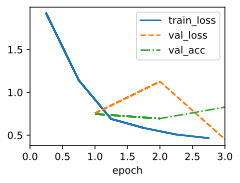

In [28]:
import torch
from d2l import torch as d2l

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the model and move it to the GPU
model = NiN(lr=0.05)
model.to(device)

# Prepare the data
data = d2l.FashionMNIST(batch_size=32, resize=(224, 224))

# Set num_workers to 0 to avoid multiprocessing issues in Jupyter on Windows
#data.num_workers = 0

# Retrieve the training data loader
train_iter = data.get_dataloader(train=True)

# Initialize model parameters
model.apply_init([next(iter(train_iter))[0].to(device)], d2l.init_cnn)

# Set up the trainer to use the GPU
trainer = d2l.Trainer(max_epochs=3, num_gpus=1)
trainer.fit(model, data)
